### Importing libraries

In [4]:
import pandas as pd
import numpy as np
from tensorflow import keras
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

### Uploading the files

In [ ]:
# Upload api token to session storage
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# The image files are no longer available on the official competition
# This dataset contained some images which were used
import kaggle
!kaggle datasets download nikitarom/planets-dataset
!unzip planets-dataset.zip

In [7]:
train_path = 'planet/planet/train-jpg'
test_path = 'planet/planet/test-jpg'
test_path_2 = 'test-jpg-additional/test-jpg-additional'

train_df = pd.read_csv('planet/planet/train_classes.csv')
test_df = pd.read_csv('planet/planet/sample_submission.csv')

In [ ]:
train_df["image_name"] = train_df["image_name"].apply(lambda x : x + '.jpg')
test_df["image_name"] = test_df["image_name"].apply(lambda x : x + '.jpg')

train_df.head(3)

### Image preprocessing

In [ ]:
# Image processed according to VGG16 architecture
data_gen = ImageDataGenerator(preprocessing_function=keras.applications.resnet50.preprocess_input,
                              validation_split = 0.25)

BATCH_SIZE = 100
TARGET_SIZE = (224,224)

train_batches = data_gen.flow_from_dataframe(dataframe=train_df,
                                             directory=train_path,
                                             x_col='image_name',
                                             y_col='tags',
                                             target_size=TARGET_SIZE,
                                             class_mode='categorical',
                                             batch_size=BATCH_SIZE,
                                             subset='training')

valid_batches = data_gen.flow_from_dataframe(dataframe=train_df,
                                             directory=train_path,
                                             x_col='image_name',
                                             y_col='tags',
                                             target_size=TARGET_SIZE,
                                             class_mode='categorical',
                                             batch_size=BATCH_SIZE,
                                             subset='validation')

test_batches = data_gen.flow_from_dataframe(dataframe=test_df,
                                            directory=test_path,
                                            x_col='image_name',
                                            y_col=None,
                                            target_size=TARGET_SIZE,
                                            class_mode=None,
                                            batch_size=BATCH_SIZE,
                                            shuffle=False)

test_batches_2 = data_gen.flow_from_dataframe(dataframe=test_df,
                                            directory=test_path_2,
                                            x_col='image_name',
                                            y_col=None,
                                            target_size=TARGET_SIZE,
                                            class_mode=None,
                                            batch_size=BATCH_SIZE,
                                            shuffle=False)

### Building our model

In [ ]:
# Using the pretrained VGG16 model
vgg16_model = keras.applications.vgg16.VGG16()

In [ ]:
model = Sequential()

# Duplicating the model
for layer in vgg16_model.layers[:-1]:
  layer.trainable = False
  model.add(layer)

model.summary()

In [ ]:
# Adding trianble dense and output layers
model.add(Dense(units=1000, activation='relu'))
model.add(Dense(units=449, activation='softmax'))
model.summary()

In [13]:
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

### Training the model

In [14]:
model_history = model.fit(x=train_batches,
                  steps_per_epoch= len(train_batches),
                  validation_data=valid_batches,
                  validation_steps=len(valid_batches),
                  epochs=6)

Epoch 1/6
304/304 [==============================] - 488s 2s/step - loss: 2.0481 - accuracy: 0.5586 - val_loss: 1.7724 - val_accuracy: 0.5901
Epoch 2/6
304/304 [==============================] - 457s 2s/step - loss: 1.6481 - accuracy: 0.6041 - val_loss: 1.7160 - val_accuracy: 0.5915
Epoch 3/6
304/304 [==============================] - 456s 2s/step - loss: 1.5221 - accuracy: 0.6206 - val_loss: 1.6751 - val_accuracy: 0.6047
Epoch 4/6
304/304 [==============================] - 457s 2s/step - loss: 1.4290 - accuracy: 0.6345 - val_loss: 1.6534 - val_accuracy: 0.6052
Epoch 5/6
304/304 [==============================] - 457s 2s/step - loss: 1.3443 - accuracy: 0.6478 - val_loss: 1.6583 - val_accuracy: 0.6014
Epoch 6/6
304/304 [==============================] - 456s 2s/step - loss: 1.2751 - accuracy: 0.6607 - val_loss: 1.6413 - val_accuracy: 0.6042


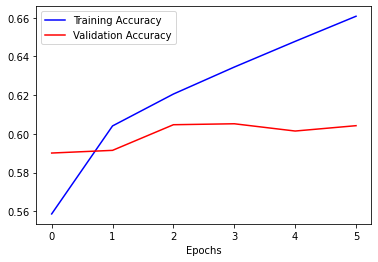

In [15]:
plt.figure()
plt.plot(model_history.history['accuracy'], 'blue')
plt.plot(model_history.history['val_accuracy'], 'red')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epochs')
plt.show()

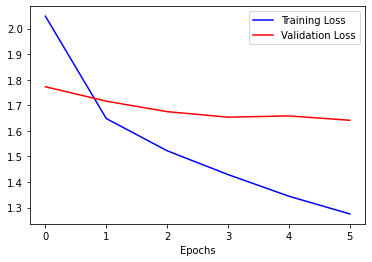

In [16]:
plt.figure()
plt.plot(model_history.history['loss'], 'blue')
plt.plot(model_history.history['val_loss'], 'red')
plt.legend(['Training Loss', 'Validation Loss'])
plt.xlabel('Epochs')
plt.show()

### Making predictions

In [17]:
test_batches.reset()
pred = model.predict(test_batches, steps=len(test_batches), verbose=10)

KeyboardInterrupt: ignored

In [ ]:
predicted_class_indices = np.argmax(pred, axis=1)

labels = (train_batches.class_indices)
labels = dict((v, k) for k, v in labels.items())
predictions = [labels[k] for k in predicted_class_indices]

file_names = test_batches.filenames
predict = pd.DataFrame(predictions, columns=['tags'])
file_name = pd.DataFrame(file_names, columns=['image_name'])[:40460]

results = pd.concat([file_name, predict], axis=1)

Additional test file

In [ ]:
test_batches_2.reset()
pred_2 = model.predict(test_batches_2, steps=len(test_batches_2), verbose=10)

In [ ]:
predicted_class_indices_2 = np.argmax(pred_2, axis=1)

labels2 = (train_batches.class_indices)
labels2 = dict((v, k) for k, v in labels2.items())
predictions_2 = [labels2[k] for k in predicted_class_indices_2]

file_names_2 = test_batches_2.filenames
predict_2 = pd.DataFrame(predictions_2, columns=['tags'])
file_name_2 = pd.DataFrame(file_names, columns=['image_name'])

results_2 = pd.concat([file_name_2, predict_2], axis=1)

In [ ]:
final_result = pd.concat([results, results_2])
final_result["image_name"] = final_result["image_name"].apply(lambda x : x.rstrip('.jpg'))
final_result.to_csv("results.csv", index=False)
pd.read_csv('results.csv').shape